# Tesis - MDM UBA - 2026

**Tariff classification using NLP**

By Santiago Tedoldi

# Using genAI models to compare or complement 

## Test sample

In [1]:
#!pip install -U openai pydantic

In [ ]:
import os
os.environ["OPENAI_API_KEY"] = "XXXXXX"

In [3]:
# Dependencies
import os
import re
import json
import time
from typing import Any, Dict, List, Optional, Tuple

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(iterable, **kwargs):
        return iterable

try:
    from openai import OpenAI
except Exception:
    OpenAI = None


Loading model training config

In [4]:
with open('results/distilbert/fft_final/final_model/training_config.json', 'r') as file:
    # The json.load() function reads the file and returns a Python object
    model_cofig = json.load(file)

with open('results/distilbert/fft_final/labels/labels_dict_FINAL_DBERT_fft_GOODS_DESCRIPTION_HS04_seed32.json', 'r') as file:
    # The json.load() function reads the file and returns a Python object
    labels_dict = json.load(file)

label2id = labels_dict["label2id"]
id2label = labels_dict["id2label"]
id2label = {int(k): v for k, v in id2label.items()}

model_cofig

{'run_name': 'FINAL_DBERT_fft_GOODS_DESCRIPTION_HS04_seed32',
 'train_type': 'fft',
 'text_col': 'GOODS_DESCRIPTION',
 'target_col': 'HS04',
 'max_length': 300,
 'batch_size': 128,
 'lr': 5e-05,
 'test_fraction': 0.01,
 'seed': 32,
 'max_epochs': 5,
 'early_stopping': True,
 'monitor': 'val_loss',
 'patience': 3,
 'min_delta': 0.0,
 'warmup_epochs': 1,
 'fine_tune': True,
 'n_finetune_layers': 0}

### Test dataset

In [5]:
data_type = {'Description': str,
             'True Label': str,
             'Top1': str,
             'Top2': str,
             'Top3': str,
             'Top4': str,
             'Top5': str,
             }

test = pd.read_csv('results/distilbert/fft_final/final_val_predictions.csv', index_col=0,
                   dtype=data_type)
test.head()

,Description,True Label,Top1,Proba Top1,Top2,Proba Top2,Top3,Proba Top3,Top4,Proba Top4,Top5,Proba Top5
354196,sterilizing cabinet,8419,9402,0.265925,9403,0.247374,9018,0.227738,8419,0.099247,8537,0.027063
155635,PERFUMES-LOVE INTETION,3303,3303,0.942016,3307,0.036050,3302,0.015176,3301,0.001438,3304,0.000576
134060,High voltage insulating tape,3920,8546,0.445084,3919,0.234640,5906,0.089700,3920,0.048213,3921,0.029814
114018,BEARING 6805 ZZ BRAND KG,8482,8482,0.995477,8483,0.000293,7319,0.000043,8711,0.000042,7009,0.000021
264869,USED SOFA 3SEATER,9403,9403,0.621796,9401,0.366761,9404,0.001297,8715,0.000630,9402,0.000514


In [6]:
len(test['True Label'].unique())

507

## OpenAI model use


In [7]:
from pydantic import BaseModel, Field

TEST_MODE = True
TEST_PROP = 0.1
TEST_ROWS = int(len(test)*TEST_PROP)

OPENAI_MODEL = "gpt-5-nano"  
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "").strip()

REQUEST_PAUSE_SECONDS = 0.3
MAX_RETRIES = 3

SAVE_DIR = "results/distilbert/fft_final/genai"
os.makedirs(SAVE_DIR, exist_ok=True)

if not TEST_MODE and not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY is empty. Set it as an environment variable before TEST_MODE=False.")

valid_hs04_codes = set(str(code).zfill(4) for code in label2id.keys())
ALL_CODES_SORTED = sorted(valid_hs04_codes)


class HS04Candidate(BaseModel):
    hs04: str = Field(pattern=r"^\d{4}$")
    confidence: float = Field(ge=0.0, le=1.0)
    reason: str

class HS04ClassificationOutput(BaseModel):
    top5_hs04: List[HS04Candidate]
    is_trustworthy: bool
    quality_score_1_to_5: int = Field(ge=1, le=5)
    needs_more_information: bool
    missing_information: str


SYSTEM_PROMPT_LLM_ONLY = """You are a senior customs analyst specialized in HS tariff classification at 4-digit level (HS04).
Experiment mode: LLM-only.
Input available: ONLY the raw product description text.
Task:
0) Analize the product description and its HS classification.
1) Return exactly 5 HS04 (headings) candidates ranked by likelihood.
2) Review your answer. 
3) Output must be strict JSON using the provided schema.
"""

_openai_client = None

def get_openai_client() -> Any:
    global _openai_client
    if _openai_client is None:
        if OpenAI is None:
            raise ImportError("`openai` package is not installed. Install/upgrade it before running with TEST_MODE=False.")
        _openai_client = OpenAI(api_key=OPENAI_API_KEY)
    return _openai_client


def normalize_hs04(value: Any) -> str:
    if pd.isna(value):
        return ""
    digits = re.sub(r"\D", "", str(value))
    if not digits:
        return ""
    return digits[-4:].zfill(4)


def safe_float(value: Any, default: float = np.nan) -> float:
    try:
        return float(value)
    except Exception:
        return default


def call_openai_structured(system_prompt: str, user_prompt: str) -> tuple[HS04ClassificationOutput, str]:
    client = get_openai_client()
    if not hasattr(client.responses, "parse"):
        raise AttributeError(
            "This OpenAI SDK version does not expose client.responses.parse. Please upgrade the `openai` package."
        )

    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = client.responses.parse(
                model=OPENAI_MODEL,
                input=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt},
                ],
                text_format=HS04ClassificationOutput,
            )

            parsed = response.output_parsed
            if parsed is None:
                raise ValueError("responses.parse returned no parsed object.")

            if isinstance(parsed, dict):
                parsed_model = HS04ClassificationOutput(**parsed)
            else:
                parsed_model = parsed

            raw_text = getattr(response, "output_text", "")
            if not raw_text:
                raw_text = parsed_model.model_dump_json()

            return parsed_model, raw_text
        except Exception as exc:
            last_error = exc
            time.sleep(0.8 * attempt)

    raise RuntimeError(f"OpenAI structured request failed after {MAX_RETRIES} retries: {last_error}")


def sanitize_output(
    parsed: HS04ClassificationOutput,
    fallback_codes: Optional[List[str]] = None,
) -> Dict[str, Any]:
    fallback_codes = fallback_codes or []
    fallback_codes = [normalize_hs04(c) for c in fallback_codes]

    cleaned_items = []
    seen = set()

    for item in parsed.top5_hs04:
        code = normalize_hs04(item.hs04)
        if not code or code in seen:
            continue
        if code not in valid_hs04_codes:
            continue
        conf = float(np.clip(safe_float(item.confidence, 0.0), 0.0, 1.0))
        reason = str(item.reason or "").strip()[:160]
        cleaned_items.append({"hs04": code, "confidence": conf, "reason": reason})
        seen.add(code)

    for code in fallback_codes + ALL_CODES_SORTED:
        if len(cleaned_items) >= 5:
            break
        if code and code in valid_hs04_codes and code not in seen:
            fallback_conf = max(0.01, 0.55 - 0.1 * len(cleaned_items))
            cleaned_items.append(
                {"hs04": code, "confidence": float(fallback_conf), "reason": "fallback code"}
            )
            seen.add(code)

    cleaned_items = sorted(cleaned_items, key=lambda x: x["confidence"], reverse=True)[:5]

    quality = int(np.clip(int(parsed.quality_score_1_to_5), 1, 5))

    return {
        "top5_hs04": cleaned_items,
        "is_trustworthy": bool(parsed.is_trustworthy),
        "quality_score_1_to_5": quality,
        "needs_more_information": bool(parsed.needs_more_information),
        "missing_information": str(parsed.missing_information or "").strip()[:240],
    }

def build_error_prediction() -> Dict[str, Any]:
    return {
        "top5_hs04": [
            {"hs04": "0000", "confidence": 0.0, "reason": "Error"}
            for _ in range(5)
        ],
        "is_trustworthy": False,
        "quality_score_1_to_5": 1,
        "needs_more_information": True,
        "missing_information": "Error",
    }


def build_prompt_llm_only(description_raw: Any) -> str:
    return (
        "Raw product description (use exactly this text as the classification basis):\n"
        f"{description_raw}\n\n"
        "Return top5 HS04 codes with confidence and concise reason for each candidate."
    )


def classify_llm_only(row: pd.Series) -> tuple[Dict[str, Any], str]:
    description_raw = row.get("Description", "")  # Raw text passed as-is

    prompt = build_prompt_llm_only(description_raw)
    parsed, raw_text = call_openai_structured(SYSTEM_PROMPT_LLM_ONLY, prompt)
    cleaned = sanitize_output(parsed)
    return cleaned, raw_text


def run_llm_only_loop(df_input: pd.DataFrame, test_mode: bool = True) -> pd.DataFrame:
    work_df = df_input.copy()
    if test_mode:
        work_df = work_df.head(TEST_ROWS).copy()

    rows = []
    iterator = tqdm(work_df.iterrows(), total=len(work_df), desc="LLM-only")

    for row_id, row in iterator:
        description_raw = row.get("Description", "")
        true_label = normalize_hs04(row.get("True Label", ""))

        error_message = ""
        try:
            pred, raw_text = classify_llm_only(row)
        except Exception as exc:
            pred = build_error_prediction()
            raw_text = ""
            error_message = str(exc)

        out = {
            "row_id": row_id,
            "Description": description_raw,
            "True Label": true_label,
            "is_trustworthy": pred["is_trustworthy"],
            "quality_score_1_to_5": pred["quality_score_1_to_5"],
            "needs_more_information": pred["needs_more_information"],
            "missing_information": pred["missing_information"],
            "error_message": error_message,
            "raw_response": raw_text,
            "process_mode": "LLM_ONLY",
        }

        for k, item in enumerate(pred["top5_hs04"], start=1):
            out[f"Top{k}"] = item["hs04"]
            out[f"Proba Top{k}"] = float(item["confidence"])
            out[f"Reason Top{k}"] = item["reason"]

        rows.append(out)

        if not test_mode and REQUEST_PAUSE_SECONDS > 0:
            time.sleep(REQUEST_PAUSE_SECONDS)

    return pd.DataFrame(rows)


print(f"TEST_MODE={TEST_MODE} | rows used={TEST_ROWS if TEST_MODE else len(test)} | model={OPENAI_MODEL}")
print(f"Valid HS04 label space size: {len(ALL_CODES_SORTED)}")

llm_only_results = run_llm_only_loop(test, test_mode=TEST_MODE)
genai_only_results = llm_only_results.copy()  # Backward-compatible alias

display(llm_only_results.head(3))

model_tag = OPENAI_MODEL.replace("-", "_")
run_tag = "test" if TEST_MODE else "full"
llm_only_path = os.path.join(SAVE_DIR, f"llm_only_predictions_{model_tag}_{run_tag}.csv")
llm_only_results.to_csv(llm_only_path, index=False)
print(f"Saved LLM-only predictions: {llm_only_path}")
print(f"Rows processed: {len(llm_only_results)} | errors: {(llm_only_results['error_message'] != '').sum()}")


TEST_MODE=True | rows used=267 | model=gpt-5-nano
Valid HS04 label space size: 1133


LLM-only:   0%|          | 0/267 [00:00<?, ?it/s]

,row_id,Description,True Label,is_trustworthy,quality_score_1_to_5,needs_more_information,missing_information,error_message,raw_response,process_mode,...,Reason Top2,Top3,Proba Top3,Reason Top3,Top4,Proba Top4,Reason Top4,Top5,Proba Top5,Reason Top5
0,354196,sterilizing cabinet,8419,True,4,False,,,"{""top5_hs04"":[{""hs04"":""8419"",""confidence"":0.42...",LLM_ONLY,...,"Instruments and appliances used in medical, su...",0101,0.15,fallback code,8417,0.15,Laboratory/industrial ovens or furnaces; if th...,8479,0.07,Other machines with specialized functions not ...
1,155635,PERFUMES-LOVE INTETION,3303,True,4,False,,,"{\n ""top5_hs04"": [\n {\n ""hs04"": ""330...",LLM_ONLY,...,Cosmetic or cosmetic-fragrance related prepara...,3302,0.50,Mixtures of odoriferous substances used in per...,3301,0.35,Essential oils base may apply if the product i...,3305,0.30,Other perfume/cosmetic preparations related to...
2,134060,High voltage insulating tape,3920,True,3,True,"Substrate material (e.g., PVC, PET, rubber), a...",,"{\n ""top5_hs04"": [\n {\n ""hs04"": ""854...",LLM_ONLY,...,Tape often has a plastic film/foil substrate; ...,3919,0.55,Self-adhesive or plastic tape can be classifie...,3920,0.45,Other plastic articles; a broad plastics headi...,4008,0.40,If the tape substrate is rubber-based (vulcani...


Saved LLM-only predictions: results/distilbert/fft_final/genai\llm_only_predictions_gpt_5_nano_test.csv
Rows processed: 267 | errors: 0


## OpenAI model complementation


In [8]:
SYSTEM_PROMPT_DISTILBERT_PLUS_LLM = """You are a senior customs analyst specialized in HS tariff classification at 4-digit level (HS04).
Experiment mode: DistilBERT + LLM complement.
Input available:
- Raw product description text.
- DistilBERT top-5 HS04 prior predictions with probabilities.
Task:
0) Analize the product description and its classification.
1) Return exactly 5 HS04 candidates ranked by likelihood.
2) Use DistilBERT output as prior evidence, but you may re-rank or challenge the candidates given, providen others.
3) Output must be strict JSON using the provided schema.
"""


def get_distilbert_prior(row: pd.Series) -> List[Dict[str, Any]]:
    prior = []

    for k in range(1, 6):
        code = normalize_hs04(row.get(f"Top{k}", ""))
        prob = safe_float(row.get(f"Proba Top{k}", np.nan), default=np.nan)

        if code:
            prior.append(
                {
                    "rank": k,
                    "hs04": code,
                    "probability": float(prob) if np.isfinite(prob) else None,
                }
            )

    return prior


def build_prompt_distilbert_plus_llm(description_raw: Any, prior: List[Dict[str, Any]]) -> str:
    prior_lines = []

    for item in prior:
        p = "nan" if item["probability"] is None else f"{item['probability']:.6f}"
        prior_lines.append(f"{item['rank']}. hs04={item['hs04']} | proba={p}")

    prior_block = "\n".join(prior_lines) if prior_lines else "(no prior predictions provided)"

    return (
        "Raw product description (use exactly this text as the classification basis):\n"
        f"{description_raw}\n\n"
        "DistilBERT prior predictions:\n"
        f"{prior_block}\n\n"
        "Return top5 HS04 codes with confidence and concise reason for each candidate."
    )


def classify_distilbert_plus_llm(row: pd.Series) -> tuple[Dict[str, Any], str]:
    description_raw = row.get("Description", "")
    prior = get_distilbert_prior(row)
    fallback_codes = [x["hs04"] for x in prior]

    prompt = build_prompt_distilbert_plus_llm(description_raw, prior)
    parsed, raw_text = call_openai_structured(SYSTEM_PROMPT_DISTILBERT_PLUS_LLM, prompt)
    cleaned = sanitize_output(parsed, fallback_codes=fallback_codes)

    return cleaned, raw_text


def run_distilbert_plus_llm_loop(df_input: pd.DataFrame, test_mode: bool = True) -> pd.DataFrame:
    work_df = df_input.copy()
    if test_mode:
        work_df = work_df.head(TEST_ROWS).copy()

    rows = []
    iterator = tqdm(work_df.iterrows(), total=len(work_df), desc="DistilBERT+LLM")

    for row_id, row in iterator:
        description_raw = row.get("Description", "")
        true_label = normalize_hs04(row.get("True Label", ""))
        error_message = ""

        try:
            pred, raw_text = classify_distilbert_plus_llm(row)
        except Exception as exc:
            fallback_codes = [x["hs04"] for x in get_distilbert_prior(row)]
            pred = build_error_prediction()
            raw_text = ""
            error_message = str(exc)

            for i, code in enumerate(fallback_codes[:5]):
                pred["top5_hs04"][i] = {
                    "hs04": code,
                    "confidence": pred["top5_hs04"][i]["confidence"],
                    "reason": "Error fallback from DistilBERT prior",
                }

        out = {
            "row_id": row_id,
            "Description": description_raw,
            "True Label": true_label,
            "is_trustworthy": pred["is_trustworthy"],
            "quality_score_1_to_5": pred["quality_score_1_to_5"],
            "needs_more_information": pred["needs_more_information"],
            "missing_information": pred["missing_information"],
            "error_message": error_message,
            "raw_response": raw_text,
            "process_mode": "DISTILBERT_PLUS_LLM",
        }

        for k, item in enumerate(pred["top5_hs04"], start=1):
            out[f"Top{k}"] = item["hs04"]
            out[f"Proba Top{k}"] = float(item["confidence"])
            out[f"Reason Top{k}"] = item["reason"]

        rows.append(out)

        if not test_mode and REQUEST_PAUSE_SECONDS > 0:
            time.sleep(REQUEST_PAUSE_SECONDS)

    return pd.DataFrame(rows)


print(f"TEST_MODE={TEST_MODE} | rows used={TEST_ROWS if TEST_MODE else len(test)} | model={OPENAI_MODEL}")

distilbert_plus_llm_results = run_distilbert_plus_llm_loop(test, test_mode=TEST_MODE)
genai_with_dbert_results = distilbert_plus_llm_results.copy()

display(distilbert_plus_llm_results.head(3))

model_tag = OPENAI_MODEL.replace("-", "_")
run_tag = "test" if TEST_MODE else "full"
hybrid_path = os.path.join(SAVE_DIR, f"distilbert_plus_llm_predictions_{model_tag}_{run_tag}.csv")

distilbert_plus_llm_results.to_csv(hybrid_path, index=False)

print(f"Saved DistilBERT+LLM predictions: {hybrid_path}")
print(f"Rows processed: {len(distilbert_plus_llm_results)} | errors: {(distilbert_plus_llm_results['error_message'] != '').sum()}")

TEST_MODE=True | rows used=267 | model=gpt-5-nano


DistilBERT+LLM:   0%|          | 0/267 [00:00<?, ?it/s]

,row_id,Description,True Label,is_trustworthy,quality_score_1_to_5,needs_more_information,missing_information,error_message,raw_response,process_mode,...,Reason Top2,Top3,Proba Top3,Reason Top3,Top4,Proba Top4,Reason Top4,Top5,Proba Top5,Reason Top5
0,354196,sterilizing cabinet,8419,True,3,True,Clarify the exact type of 'sterilizing cabinet...,,"{\n ""top5_hs04"": [\n {\n ""hs04"": ""940...",DISTILBERT_PLUS_LLM,...,Parts and accessories of medical furniture; pl...,9018,0.227738,Instruments and apparatus for analysis or ster...,8419,0.099247,Equipment for treatment of materials by heat o...,8537,0.027063,Electrical apparatus for switching/protecting ...
1,155635,PERFUMES-LOVE INTETION,3303,True,5,False,,,"{""top5_hs04"":[{""hs04"":""3303"",""confidence"":0.94...",DISTILBERT_PLUS_LLM,...,Next closest fragrance-related subheading; pla...,3302,0.015176,Mixtures of odoriferous substances used in per...,3301,0.001438,Essential oils or fragrance concentrates used ...,3304,0.000576,Cosmetics/beauty preparations; unlikely primar...
2,134060,High voltage insulating tape,3920,True,4,False,,,"{""top5_hs04"":[{""hs04"":""8547"",""confidence"":0.60...",DISTILBERT_PLUS_LLM,...,Electrical insulation materials category; plau...,3919,0.080000,Tape may be plastic-based self-adhesive film/s...,3920,0.050000,Plastic film/sheet backing for tape; falls und...,3921,0.020000,Other plastic sheets/films; less specific but ...


Saved DistilBERT+LLM predictions: results/distilbert/fft_final/genai\distilbert_plus_llm_predictions_gpt_5_nano_test.csv
Rows processed: 267 | errors: 0


## Evaluation 

,model_name,n_samples,iteration,top_1_acc,top_2_acc,top_3_acc,top_4_acc,top_5_acc
0,DBERT_FFT,267,0,0.606742,0.734082,0.786517,0.827715,0.846442
1,GenAI_gpt-5-nano,267,0,0.434457,0.546816,0.610487,0.651685,0.692884
2,DBERT_FFT+GenAI_gpt-5-nano,267,0,0.591760,0.726592,0.775281,0.823970,0.850187


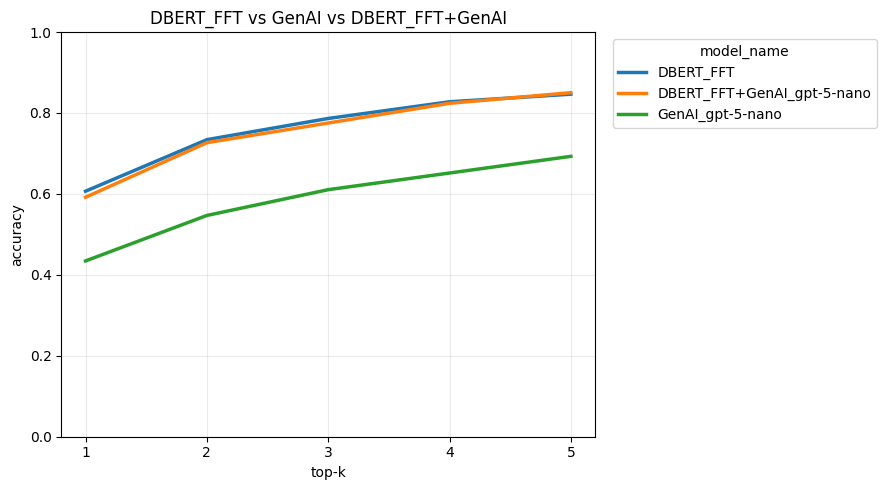

Saved evaluation metrics: results/distilbert/fft_final/genai\evaluation_metrics_gpt_5_nano_test.csv
Rows evaluated consistently across methods: 267


In [10]:
def normalize_prediction_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["True Label"] = out["True Label"].apply(normalize_hs04)
    for k in range(1, 6):
        col = f"Top{k}"
        if col in out.columns:
            out[col] = out[col].apply(normalize_hs04)
    return out


def compute_topk_accuracy(df_pred: pd.DataFrame, model_name: str) -> Dict[str, Any]:
    metrics = {"model_name": model_name, "n_samples": len(df_pred), "iteration": 0}

    if len(df_pred) == 0:
        for k in range(1, 6):
            metrics[f"top_{k}_acc"] = np.nan
        return metrics

    for k in range(1, 6):
        cols = [f"Top{i}" for i in range(1, k + 1)]
        hit = df_pred.apply(
            lambda row: row["True Label"] in {row[c] for c in cols if row.get(c, "")},
            axis=1,
        )
        metrics[f"top_{k}_acc"] = float(hit.mean())

    return metrics


TOPK_COLS = [f"top_{k}_acc" for k in range(1, 6)]


def to_long_topk(
    df: pd.DataFrame,
    id_cols: List[str],
    topk_cols: List[str] = TOPK_COLS,
    acc_name: str = "acc",
) -> pd.DataFrame:
    missing = [c for c in topk_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing top-k columns: {missing}")

    out = df.melt(
        id_vars=id_cols,
        value_vars=topk_cols,
        var_name="topk",
        value_name=acc_name,
    ).copy()

    out["topk"] = out["topk"].str.extract(r"top_(\d+)_acc").astype(int)
    return out


def plot_topk_variability(
    df_long: pd.DataFrame,
    group_col: str,
    iteration_col: str = "iteration",
    x_col: str = "topk",
    y_col: str = "acc",
    title: Optional[str] = None,
    figsize: tuple = (9, 5),
):
    needed = {group_col, iteration_col, x_col, y_col}
    missing = needed - set(df_long.columns)
    if missing:
        raise ValueError(f"df_long missing columns: {sorted(missing)}")

    data = df_long.copy().sort_values([group_col, iteration_col, x_col])
    fig, ax = plt.subplots(figsize=figsize)

    for g, gdf in data.groupby(group_col, sort=False):
        stats = (
            gdf.groupby(x_col)[y_col]
            .agg(["mean"])
            .reset_index()
            .sort_values(x_col)
        )
        ax.plot(
            stats[x_col].values,
            stats["mean"].values,
            marker=None,
            linewidth=2.5,
            label=str(g),
        )

    ax.set_xlabel("top-k")
    ax.set_ylabel("accuracy")
    ax.set_xticks(sorted(data[x_col].unique()))
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.25)

    if title:
        ax.set_title(title)

    ax.legend(title=group_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


eval_input = test.head(TEST_ROWS).copy() if TEST_MODE else test.copy()
eval_input = eval_input.reset_index().rename(columns={"index": "row_id"})

if "row_id" not in genai_only_results.columns or "row_id" not in genai_with_dbert_results.columns:
    raise ValueError("Missing row_id columns in GenAI result dataframes.")

common_row_ids = sorted(
    set(eval_input["row_id"])
    .intersection(set(genai_only_results["row_id"]))
    .intersection(set(genai_with_dbert_results["row_id"]))
)

base_eval = eval_input[eval_input["row_id"].isin(common_row_ids)].copy()

dbert_eval = normalize_prediction_df(
    base_eval[["row_id", "Description", "True Label", "Top1", "Top2", "Top3", "Top4", "Top5"]]
)

genai_eval = normalize_prediction_df(
    genai_only_results[
        genai_only_results["row_id"].isin(common_row_ids)
    ][["row_id", "Description", "True Label", "Top1", "Top2", "Top3", "Top4", "Top5"]]
)

genai_dbert_eval = normalize_prediction_df(
    genai_with_dbert_results[
        genai_with_dbert_results["row_id"].isin(common_row_ids)
    ][["row_id", "Description", "True Label", "Top1", "Top2", "Top3", "Top4", "Top5"]]
)

metrics_df = pd.DataFrame(
    [
        compute_topk_accuracy(dbert_eval, "DBERT_FFT"),
        compute_topk_accuracy(genai_eval, f"GenAI_{OPENAI_MODEL}"),
        compute_topk_accuracy(genai_dbert_eval, f"DBERT_FFT+GenAI_{OPENAI_MODEL}"),
    ]
)

display(metrics_df)

metrics_long = to_long_topk(
    metrics_df,
    id_cols=["model_name", "n_samples", "iteration"],
    topk_cols=TOPK_COLS,
    acc_name="acc",
)

plot_topk_variability(
    metrics_long,
    group_col="model_name",
    iteration_col="iteration",
    x_col="topk",
    y_col="acc",
    title="DBERT_FFT vs GenAI vs DBERT_FFT+GenAI",
)

run_tag = "test" if TEST_MODE else "full"
metrics_path = os.path.join(SAVE_DIR, f"evaluation_metrics_{OPENAI_MODEL.replace('-', '_')}_{run_tag}.csv")
metrics_df.to_csv(metrics_path, index=False)

print(f"Saved evaluation metrics: {metrics_path}")
print(f"Rows evaluated consistently across methods: {len(common_row_ids)}")